In [ ]:
"""
Implementation of a Dirichelet Variational AutoEncoder using an inverse gamma approximation for a MNIST dataset 
I will use a simple Enconder architecture to start:
Encoder:
    Linear(784 - 500)
    BatchNorm()
    ReLU()
    Linear(400 - 50)
    Softplus()

The Latent Variable Z will have d=50 dimensions

Decoder:
    Linear(50 - 500)
    BatchNorm()
    ReLU()
    Linear(500 - 784)
"""

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Uniform
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import math

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from plotting import make_vae_plots
torch.manual_seed(44)

EPS = 1e-8

class MLPEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims),
            nn.BatchNorm1d(hidden_dims),
            nn.ReLU(),

            nn.Linear(hidden_dims, latent_dim),
            
        )
    def forward(self, x):
        out = self.net(x)

        # softplus to ensure positive alpha_hat
        alpha_hat = F.softplus(out) + EPS
        alpha_hat = alpha_hat.clamp(min=1e-5, max=1e3) 
        return alpha_hat
    
class BernoulliDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dims, output_dim):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dims), 
            nn.BatchNorm1d(hidden_dims), 
            nn.ReLU(),
            nn.Linear(hidden_dims, output_dim)
        )

    def forward(self, z):
        logits = self.net(z)
        # return logits (use BCEWithLogitsLoss)
        return logits
    
class DirVAE(nn.Module):
    def __init__(self, input_dim, enc_hidden_dims, dec_hidden_dims, latent_dim,
                 prior_alpha=None, beta=1.0):
        """
        input_dim: flattened input size (e.g. 28*28)
        enc_hidden_dims:  encoder hidden sizes
        dec_hidden_dims:  decoder hidden sizes
        latent_dim: K

        prior_alpha: vector or scalar for Dirichlet prior concentration alpha (if scalar, replicate)
        beta: rate parameter for Gammas (paper uses beta=1)
        """
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = MLPEncoder(input_dim, enc_hidden_dims, latent_dim)
        self.decoder = BernoulliDecoder(latent_dim, dec_hidden_dims, input_dim)

        if prior_alpha is None:
            # default weak symmetric prior; user can override
            prior_alpha = torch.ones(latent_dim) * 0.98
        elif torch.is_tensor(prior_alpha):
            if prior_alpha.numel() == 1:
                prior_alpha = prior_alpha.repeat(latent_dim)
        else:
            # numeric scalar
            prior_alpha = torch.tensor(float(prior_alpha)).repeat(latent_dim)
        self.register_buffer('prior_alpha', prior_alpha.float())
        self.beta = float(beta)

    def inverse_gamma_cdf_approx(self, u, alpha):
        """
        Approximate inverse CDF for X ~ Gamma(alpha, beta) using:
        F^{-1}(u; alpha, beta) ≈ beta^{-1} * (u * alpha * Gamma(alpha))^{1/alpha}
        u: uniform samples in (0,1), shape (batch, K)
        alpha: shape (batch, K) or (K,)
        returns: approx gamma samples shape (batch, K)
        """
        # alpha * Gamma(alpha) = alpha * exp(lgamma(alpha))
        #print(alpha.max())
        alpha = alpha.clamp(min=1e-5, max=1e3)
        #print(alpha.max())

        # shapes broadcast
        log_gamma = torch.lgamma(alpha)
        a_gamma = alpha * torch.exp(log_gamma)  # shape (batch, K)
        # clamp u to (eps, 1)
        u = u.clamp(min=EPS, max=1.0 - 1e-12)
        base = u * a_gamma
        # to avoid negative/zero values due to numerical issues, clamp base
        base = base.clamp(min=EPS)
        # power 1/alpha
        samples = (base) ** (1.0 / alpha)

        # divide by beta (rate)
        samples = samples / (self.beta)
        return samples
    
    def sample_dirichlet_from_alpha(self, alpha_hat):
        """
        Given alpha_hat (batch, K), produce reparam samples z on simplex:
          1) draw u ~ Uniform(0,1) per component
          2) approximate gamma sample via inverse Gamma CDF approx
          3) normalize v -> z = v / sum_k v_k
        Returns z (batch, K), v (batch, K), u (for reproducibility)
        """

        # Number of observations
        batch = alpha_hat.shape[0]

        # Uniform draws per component
        u = torch.rand_like(alpha_hat)  # Uniform(0,1), shape(K,)

        v = self.inverse_gamma_cdf_approx(u, alpha_hat)
        # Normalize to get Dirichlet sample
        denom = v.sum(dim=1, keepdim=True).clamp(min=EPS)
        z = v / denom


        return z, v, u
    
    def forward(self, x):
        """
        x: flattened input (batch, input_dim) with values in [0,1] for Bernoulli decoding
        returns: reconstruction logits, z, alpha_hat, v
        """

        # Encoder step to get the posterior parameters
        alpha_hat = self.encoder(x)  # (batch, K)

        # Sample from posterior 
        z, v, u = self.sample_dirichlet_from_alpha(alpha_hat)  # z in simplex

        # Decoder step
        logits = self.decoder(z)  # (batch, input_dim)
        return logits, z, alpha_hat, v
    


def multi_gamma_kl(alpha_hat, prior_alpha):
    """
    KL between MultiGamma(alpha_hat, beta=1) and MultiGamma(prior_alpha, beta=1)
    Per paper (Equation 3):
      KL(Q||P) = sum_k [ log Gamma(alpha_k) - log Gamma(alpha_hat_k)
                         + (alpha_hat_k - alpha_k) * psi(alpha_hat_k) ]

    alpha_hat: (batch, K)
    prior_alpha: (K,) or (batch, K)
    Returns scalar KL (averaged over batch).
    """
    # Broadcast prior_alpha to batch if necessary
    if prior_alpha.dim() == 1:
        prior = prior_alpha.unsqueeze(0).expand_as(alpha_hat)
    else:
        prior = prior_alpha

    # Compute the KL components
    term1 = torch.lgamma(prior) - torch.lgamma(alpha_hat)
    term2 = (alpha_hat - prior) * torch.digamma(alpha_hat)
    kl_comp = term1 + term2
    kl = kl_comp.sum(dim=1)  # per example sum over latent dimensions

    return kl.mean()

    
def dirvae_elbo_loss(model, x):
    """
    Compute negative ELBO (loss to minimize) for Bernoulli decoder.
    x: (batch, input_dim) values in {0,1} or [0,1]
    returns loss (scalar), recon_loss (scalar), kl (scalar), z (tensor)
    """
    logits, z, alpha_hat, v = model(x)

    # Reconstruction: bernoulli likelihood -> BCEWithLogits
    bce = F.binary_cross_entropy_with_logits(logits, x, reduction='none')
    recon_per_sample = bce.sum(dim=1)  # per example reconstruction negative log-likelihood
    
    # Compute the mean for the batch
    recon_loss = recon_per_sample.mean()

    # KL between MultiGamma post (alpha_hat) and prior MultiGamma (prior_alpha)
    kl = multi_gamma_kl(alpha_hat, model.prior_alpha)
    
    # ELBO = E_q[log p(x|z)] - KL -> loss = -ELBO = recon_loss + KL
    loss = recon_loss + kl
    return loss, recon_loss, kl, z


def train_loop(model, optimizer, train_loader, device):
        
        tot_loss = 0.0
        tot_recon = 0.0
        tot_kl = 0.0
        n_samples = 0
        model.train()

        for x, _ in train_loader:
            x = x.to(device)

            #Reset Gradients
            optimizer.zero_grad()

            #Foward Pass
            loss, recon, kl, _ = dirvae_elbo_loss(model, x)

            #BackProp
            loss.backward()
            optimizer.step()

            batch_size = x.size(0)
            tot_loss += loss.item() * batch_size
            tot_recon += recon.item() * batch_size
            tot_kl += kl.item() * batch_size
            n_samples += batch_size

        mean_loss = tot_loss / n_samples
        mean_recon = tot_recon / n_samples
        mean_kl = tot_kl / n_samples

        print(f"Negative ELBO: {mean_loss:.4f} | Recon Loss: {mean_recon:.4f} | KL: {mean_kl:.4f}")

        return mean_loss, mean_recon, mean_kl          

def test_loop(model, test_loader, device):

    model.eval()
    tot_loss, tot_recon, tot_kl = 0.0, 0.0, 0.0
    n_samples = 0

    with torch.no_grad():
        labels = [] # For visualiation
        zs = [] # For visualization

        for x, label in test_loader:
            x = x.to(device)

            # Foward Pass
            loss, recon, kl, z = dirvae_elbo_loss(model, x)

            batch_size = x.size(0)
            tot_loss += loss.item() * batch_size
            tot_recon += recon.item() * batch_size
            tot_kl += kl.item() * batch_size
            n_samples += batch_size

            labels.append(label)
            zs.append(z)

    mean_loss = tot_loss / n_samples
    mean_recon = tot_recon / n_samples
    mean_kl = tot_kl / n_samples
    print(f"Negative ELBO: {mean_loss:.4f} | Recon Loss: {mean_recon:.4f} | KL: {mean_kl:.4f}")

    labels = torch.cat(labels, dim=0)
    zs = torch.cat(zs, dim=0)
    
    return mean_loss, mean_recon, mean_kl

def dirichlet_log_prob(z, alpha, eps=1e-8):
    """
    log Dir(z | alpha) = lgamma(sum(alpha)) - sum(lgamma(alpha)) + sum((alpha - 1)*log z)
    """
    z = z.clamp(min=eps)
    alpha_sum = alpha.sum(dim=-1)
    return (
        torch.lgamma(alpha_sum)
        - torch.lgamma(alpha).sum(dim=-1)
        + ((alpha - 1) * z.log()).sum(dim=-1)
    )

@torch.no_grad()
def montecarlo_nll(model, data_loader, device, K=500):
    """
    Monte Carlo (importance-weighted) estimate of the marginal log-likelihood:
        p(x) ≈ (1/K) Σ_i p(x|z_i)p(z_i)/q(z_i)
    Returns the mean NLL (nats per image) as in Proposition A.1 of DirVAE.
    """
    model.eval()
    total_nll = 0.0
    n_samples = 0

    for x, _ in data_loader:
        x = x.to(device)
        B = x.size(0)

        # ---- 1) Encode: q(z|x) = Dirichlet(alpha_hat)
        alpha_hat = model.encoder(x)  # (B, latent_dim)

        # ---- 2) Sample z_i ~ q(z|x) using model’s internal Dirichlet sampler
        # repeat alpha_hat K times (for K importance samples)
        alpha_rep = alpha_hat.unsqueeze(0).expand(K, -1, -1).contiguous().view(-1, alpha_hat.size(1))
        z, v, u = model.sample_dirichlet_from_alpha(alpha_rep)  # (K*B, latent_dim)
        z = z.view(K, B, -1)

        # ---- 3) Compute p(x|z_i)
        logits = model.decoder(z.view(-1, model.latent_dim))  # (K*B, input_dim)
        log_p_x_given_z = -F.binary_cross_entropy_with_logits(
            logits, x.repeat(K, 1), reduction="none"
        ).sum(dim=1)
        log_p_x_given_z = log_p_x_given_z.view(K, B)

        # ---- 4) Compute p(z_i) and q(z_i|x)
        prior_alpha = model.prior_alpha.to(device).view(1, 1, -1).expand_as(z)
        post_alpha = alpha_hat.view(1, B, -1).expand_as(z)
        log_p_z = dirichlet_log_prob(z, prior_alpha)  # (K, B)
        log_q_z = dirichlet_log_prob(z, post_alpha)   # (K, B)

        # ---- 5) Importance weights w_i = p(x|z_i)p(z_i)/q(z_i)
        log_w = log_p_x_given_z + log_p_z - log_q_z   # (K, B)

        # ---- 6) Monte Carlo marginal log-likelihood (log-sum-exp trick)
        log_w_max, _ = torch.max(log_w, dim=0, keepdim=True)
        log_p_x = log_w_max.squeeze(0) + torch.log(
            torch.exp(log_w - log_w_max).mean(dim=0)
        ) - math.log(K)

        # ---- 7) Average over batch
        batch_nll = (-log_p_x).sum().item()
        total_nll += batch_nll
        n_samples += B

    mean_nll = total_nll / n_samples
    print(f"Estimated NLL (Monte Carlo, K={K}): {mean_nll:.4f}")
    return mean_nll

def train_from_scratch(model, train_loader, test_loader, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    for epoch in range(1, 51 ):
        print(f"Epoch {epoch}")
        print("--------")
        mean_train_loss, mean_train_recon, mean_train_kl = train_loop(model, optimizer, train_loader, device)
        print("")
 
    #### Small Visualization
        if epoch % 5 == 0:
            model.eval()
            with torch.no_grad():

                batch, _ = next(iter(test_loader))
                batch = batch[:16].to(device)
                x = batch  
                # Forward pass (posterior sample)
                logits, z, alpha_hat, _ = model(x)
                recon_imgs = torch.sigmoid(logits).view(-1, 1, 28, 28)

                # Stack originals (top) and reconstructions (bottom)
                comparison = torch.cat([x.view(-1, 1, 28, 28), recon_imgs])
                torchvision.utils.save_image(
                    comparison,
                    f"slack_code/DirVAE/recon_images/recon_test_epoch_{epoch:02d}.png",
                    nrow=16
                )
                
    return model


In [12]:
if __name__ == "__main__":

    if torch.cuda.is_available():
        device = torch.device("cuda")
    #### IMPORTANT, the torch.gamma and torch.digamma explode when using mps (floating point errors)
   #  elif torch.backends.mps.is_available():
   #  device = torch.device("mps")
    else:
        device = torch.device("cpu")

    print("Current device:", device)
        
    # Simple binarization transform
    transform = T.Compose([
    T.ToTensor(),         
    lambda t: t.view(-1)   
        ])
    trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    def filter_mnist(dataset, keep):
        mask = torch.isin(dataset.targets, torch.tensor(keep))
        dataset.data = dataset.data[mask]
        dataset.targets = dataset.targets[mask]
        return dataset

    # trainset = filter_mnist(trainset, keep=[3, 7])
    # testset = filter_mnist(testset, keep=[3, 7])

    train_loader = DataLoader(trainset, batch_size=100, shuffle=True, num_workers=0)
    test_loader = DataLoader(testset, batch_size=100, shuffle=True, num_workers = 0)

    input_dim = 28 * 28
    latent_dim = 10

    model = DirVAE(input_dim=input_dim,
                   enc_hidden_dims=500,
                   dec_hidden_dims=500,
                   latent_dim=latent_dim,
                   prior_alpha=0.98).to(device)

    if latent_dim == 50:
        # Check if trained model exists
        if os.path.exists("slack_code/DirVAE/DirVAE_checkpoint_50.pth"):
            model.load_state_dict(torch.load("slack_code/DirVAE/DirVAE_checkpoint_50.pth", weights_only=True, map_location=device))
        else:
            model = train_from_scratch(model, train_loader, test_loader, device)
            torch.save(model.state_dict(), "slack_code/DirVAE/DirVAE_checkpoint_50.pth")

    elif latent_dim ==10:
         # Check if trained model exists
        if os.path.exists("slack_code/DirVAE/DirVAE_checkpoint_10.pth"):
            model.load_state_dict(torch.load("slack_code/DirVAE/DirVAE_checkpoint_10.pth", weights_only=True, map_location=device))
        else:
            model = train_from_scratch(model, train_loader, test_loader, device)
            torch.save(model.state_dict(), "slack_code/DirVAE/DirVAE_checkpoint_10.pth")
    
    else:
         # Check if trained model exists
        if os.path.exists(f"slack_code/DirVAE/DirVAE_checkpoint_{latent_dim}.pth"):
            model.load_state_dict(torch.load(f"slack_code/DirVAE/DirVAE_checkpoint_{latent_dim}.pth", weights_only=True, map_location=device))
        else:
            model = train_from_scratch(model, train_loader, test_loader, device)
            torch.save(model.state_dict(), f"slack_code/DirVAE/DirVAE_checkpoint_{latent_dim}.pth")


    print("-------------")
    print("Test Results:")
    mean_test_loss, mean_test_recon, mean_test_kl = test_loop(model, test_loader, device)
    montecarlo_nll(model, test_loader, device, K=500)

Current device: cpu
-------------
Test Results:
Negative ELBO: 127.7480 | Recon Loss: 112.5141 | KL: 15.2339
Estimated NLL (Monte Carlo, K=500): 117.3560


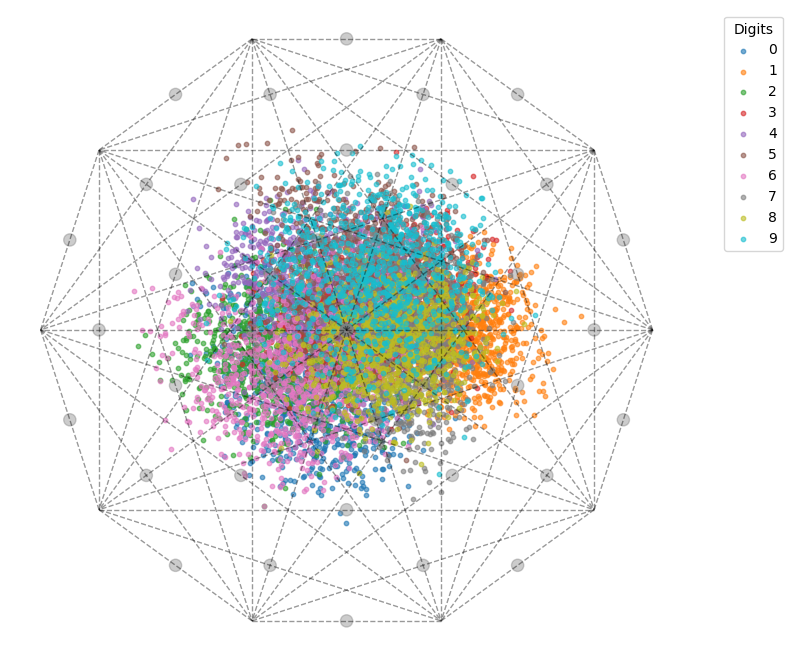

In [13]:
from plots.simplex import plot_mnist_simplex
latents = []
labels = []

for x, y in test_loader:
    x = x.to(device)
    with torch.no_grad():
        logits, z, alpha_hat, v = model(x)
    latents.append(z.cpu().numpy())
    labels.append(y.numpy())

latent_matrix = np.vstack(latents)
labels = np.hstack(labels)


plot_mnist_simplex(latent_matrix, labels, latent_dim=10)

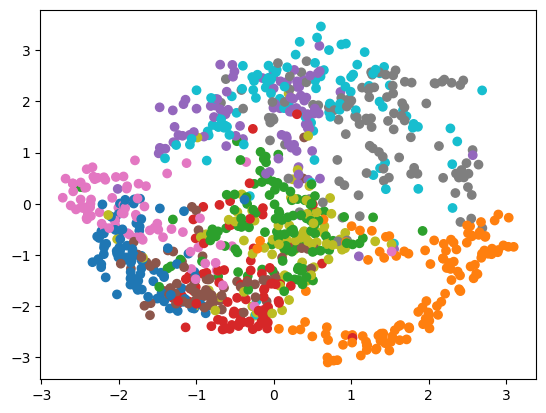

In [14]:
from plotting import *
zs = []
ys = []

n = 0
model.eval()

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
        n += y.shape[0]
        logits, z, alpha_hat, v = model(x)
        zs.append(z.detach().cpu())
        ys.append(y.detach().cpu())

        if n >= 1000:
            break

zs = torch.cat(zs, dim=0)
ys = torch.cat(ys, dim=0)

fig, ax = plt.subplots()
plot_latents(ax, zs, ys, latent_dim)
plt.show()
